In [ ]:
!fusermount -u /content/drive
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


fusermount: failed to unmount /content/drive: No such file or directory
Mounted at /content/drive


In [ ]:
import os
import zipfile

# Define the path where you uploaded the zip file
ZIP_FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/slit_pro/processed"

# Define the folder where you want to extract it
EXTRACT_PATH = "/content/drive/MyDrive/Colab Notebooks/slit_pro/processed_new"

# Extract the zip file
with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✅ Dataset extracted successfully!")



✅ Dataset extracted successfully!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cataract Images: 2944, Normal Images: 3216


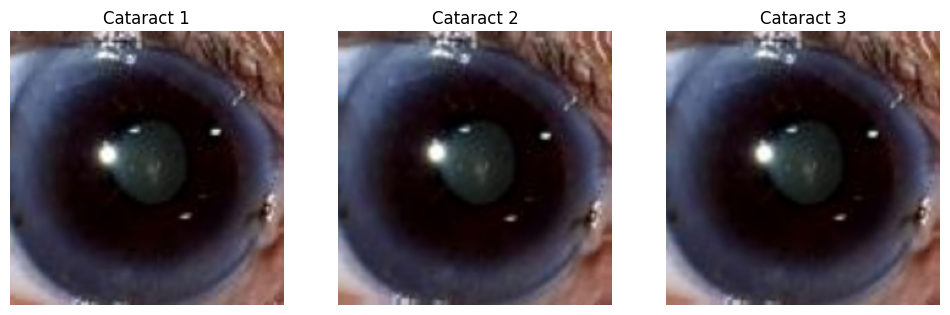

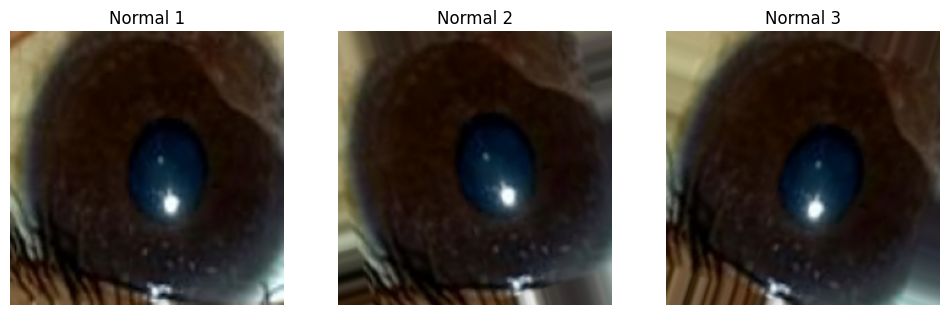

In [ ]:
import os
import zipfile
import cv2
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

extract_path = '/content/drive/MyDrive/Colab Notebooks/slit_pro/augmented'


# Define Cataract and Normal image directories
cataract_dir = os.path.join(extract_path, 'cataract')
normal_dir = os.path.join(extract_path, 'Normal')

# Get image lists
cataract_images = [f for f in os.listdir(cataract_dir) if f.endswith(('jpg', 'png'))]
normal_images = [f for f in os.listdir(normal_dir) if f.endswith(('jpg', 'png'))]

# Print image count
print(f"Cataract Images: {len(cataract_images)}, Normal Images: {len(normal_images)}")

# Function to display sample images
def display_samples(image_list, folder, title, num_samples=3):
    fig, axes = plt.subplots(1, num_samples, figsize=(12, 4))
    for i, img_name in enumerate(image_list[:num_samples]):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"{title} {i+1}")
    plt.show()

# Display sample images from both categories
display_samples(cataract_images, cataract_dir, "Cataract")
display_samples(normal_images, normal_dir, "Normal")


png conversion


In [ ]:
import os
from PIL import Image

# ✅ Paths
input_folder = "/content/drive/MyDrive/Colab Notebooks/fundus_/cataract"  # Original Cataract images
output_folder = "/content/drive/MyDrive/Colab Notebooks/fundus_/Cataract_New"  # New folder to save PNG images

# ✅ Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# ✅ Convert all images in the Cataract folder to PNG
for file in os.listdir(input_folder):
    file_path = os.path.join(input_folder, file)

    if os.path.isfile(file_path) and file.lower().endswith(('.jpg', '.jpeg', '.png')):  # Check for image files
        with Image.open(file_path) as img:
            output_path = os.path.join(output_folder, file.split('.')[0] + '.png')  # Change file extension to .png
            img.save(output_path, 'PNG')  # Save the image as PNG

print("✅ Cataract images converted to PNG and saved in Cataract_New folder!")


✅ Cataract images converted to PNG and saved in Cataract_New folder!


In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

# ✅ Paths
input_folder_cataract = '/content/drive/MyDrive/Colab Notebooks/slit_pro/augmented/cataract'  # Cataract folder
input_folder_normal = '/content/drive/MyDrive/Colab Notebooks/slit_pro/augmented/Normal'  # Normal folder
output_folder = '/content/drive/MyDrive/Colab Notebooks/slit_pro/proc_aug_clahe'  # Preprocessed folder inside fundus
IMG_SIZE = (224, 224)  # Resized image size

# ✅ Ensure output folder exists
os.makedirs(output_folder, exist_ok=True)
os.makedirs(os.path.join(output_folder, 'cataract'), exist_ok=True)
os.makedirs(os.path.join(output_folder, 'Normal'), exist_ok=True)

# ✅ Function to apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
def apply_clahe(img):
    # Convert image to LAB color space
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to the L channel
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)

    # Merge back the channels
    limg = cv2.merge((cl, a, b))

    # Convert back to BGR color space
    return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

# ✅ Function to resize image while keeping aspect ratio
def resize_with_padding(img, target_size):
    old_size = img.shape[:2]  # (height, width)
    ratio = min(target_size[0] / old_size[1], target_size[1] / old_size[0])  # Scaling factor
    new_size = (int(old_size[1] * ratio), int(old_size[0] * ratio))  # New dimensions
    img_resized = cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)

    # Create a blank white canvas
    canvas = np.full((target_size[1], target_size[0], 3), 255, dtype=np.uint8)
    start_x = (target_size[0] - new_size[0]) // 2
    start_y = (target_size[1] - new_size[1]) // 2
    canvas[start_y:start_y + new_size[1], start_x:start_x + new_size[0]] = img_resized

    return canvas

# ✅ Function to process images
def process_images(input_folder, category):
    # Get the output path for this category inside preprocessed folder
    output_category_folder = os.path.join(output_folder, category)

    # Process images in the folder
    for file in tqdm(os.listdir(input_folder), desc=f"Processing {category} images"):
        file_path = os.path.join(input_folder, file)

        if os.path.isfile(file_path) and file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = cv2.imread(file_path)
            if img is None:
                print(f"Skipping unreadable image: {file_path}")
                continue

            # ✅ Apply CLAHE
            img_clahe = apply_clahe(img)

            # ✅ Resize image
            img_resized = resize_with_padding(img_clahe, IMG_SIZE)

            # ✅ Save processed image as PNG in the preprocessed folder
            output_path = os.path.join(output_category_folder, f"{os.path.splitext(file)[0]}.png")
            cv2.imwrite(output_path, img_resized)

# ✅ Process both cataract and normal images
process_images(input_folder_cataract, 'cataract')
process_images(input_folder_normal, 'Normal')

print("✅ Preprocessing complete for both cataract and normal images inside fundus!")


Processing Normal images: 100%|██████████| 3216/3216 [02:39<00:00, 20.15it/s]

✅ Preprocessing complete for both cataract and normal images inside fundus!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


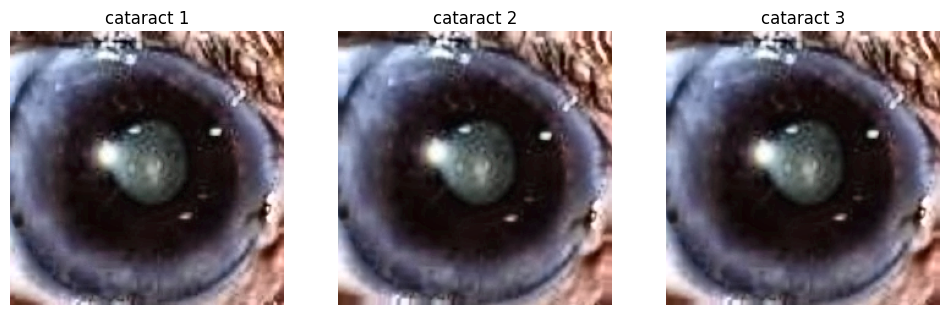

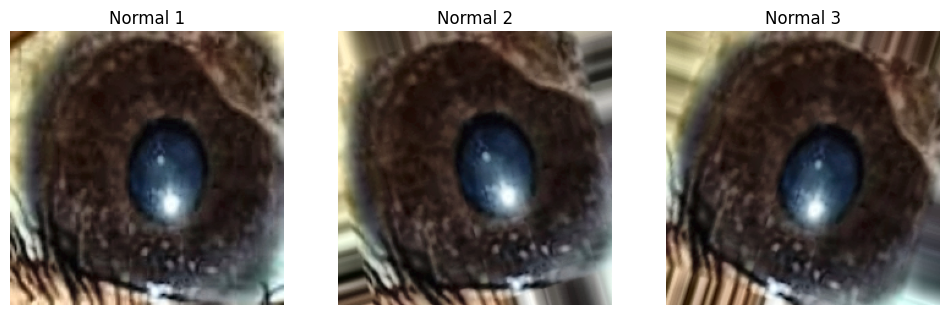

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define input directory
input_dir = '/content/drive/MyDrive/Colab Notebooks/slit_pro/proc_aug_clahe'  # Change this to your dataset path

# Define categories
categories = ['cataract', 'Normal']  # Update if you have different categories

# Function to display sample images
def display_samples(category, num_samples=3):
    category_dir = os.path.join(input_dir, category)
    if not os.path.exists(category_dir):
        print(f"Category folder '{category}' not found!")
        return

    images = [f for f in os.listdir(category_dir) if f.endswith(('jpg', 'png'))]
    if len(images) == 0:
        print(f"No images found in '{category}' folder!")
        return

    fig, axes = plt.subplots(1, min(num_samples, len(images)), figsize=(12, 4))
    for i, img_name in enumerate(images[:num_samples]):
        img_path = os.path.join(category_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if num_samples > 1:
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(f"{category} {i+1}")
        else:
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"{category} 1")

    plt.show()

# Display images for each category
for category in categories:
    display_samples(category)


In [ ]:
!pip uninstall -y tensorflow tensorflow-addons vit-keras keras


Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
Found existing installation: tensorflow-addons 0.20.0
Uninstalling tensorflow-addons-0.20.0:
  Successfully uninstalled tensorflow-addons-0.20.0
Found existing installation: vit-keras 0.1.2
Uninstalling vit-keras-0.1.2:
  Successfully uninstalled vit-keras-0.1.2
Found existing installation: keras 3.8.0
Uninstalling keras-3.8.0:
  Successfully uninstalled keras-3.8.0


train_test split80-20


In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

# Your folder where all anterior images are dumped
original_data_dir = '/content/drive/MyDrive/Colab Notebooks/slit_pro/proc_aug_clahe'

# Target folders
train_dir = '/content/drive/MyDrive/Colab Notebooks/slit_pro/proc_aug_clahe/train'
test_dir = '/content/drive/MyDrive/Colab Notebooks/slit_pro/proc_aug_clahe/test'

# Make folders if not exists
for folder in [train_dir, test_dir]:
    os.makedirs(os.path.join(folder, 'cataract'), exist_ok=True)
    os.makedirs(os.path.join(folder, 'Normal'), exist_ok=True)

# Assuming image names or a CSV tells you label mapping:
# Eg: image001.jpg --> cataract  | image002.jpg --> normal
# If not, and folders are already separated → even easier!

all_images = []
labels = []

for label in ['cataract', 'Normal']:
    path = os.path.join(original_data_dir, label)
    images = os.listdir(path)
    for img in images:
        all_images.append(os.path.join(path, img))
        labels.append(label)

# Split (80% train, 20% test)
train_imgs, test_imgs, train_labels, test_labels = train_test_split(all_images, labels, stratify=labels, test_size=0.2, random_state=42)

# Copy to respective folders
def copy_files(img_list, label_list, target_dir):
    for img, label in zip(img_list, label_list):
        dest = os.path.join(target_dir, label, os.path.basename(img))
        shutil.copy(img, dest)

copy_files(train_imgs, train_labels, train_dir)
copy_files(test_imgs, test_labels, test_dir)

print("Split complete! Check your Drive folders 🚀")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Split complete! Check your Drive folders 🚀


In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load Pre-trained VGG16 model (without the classification head)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Define dataset path
dataset_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/train"

# Function to extract features
def extract_features(directory):
    data = []
    labels = []

    for category in os.listdir(directory):  # Cataract, Normal
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)

                # Load image and preprocess
                img = load_img(img_path, target_size=(224, 224))
                img_array = img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)  # Normalize for VGG16

                # Extract features
                features = base_model.predict(img_array)
                features = features.flatten()  # Flatten the feature map

                # Append to data
                data.append(features)
                labels.append(1 if category.lower() == "cataract" else 0)  # Convert to binary (Cataract=1, Normal=0)
  # Label (Cataract or Normal)

    return np.array(data), np.array(labels), features # Return features from the last iteration


# Extract features from dataset
X, y, features = extract_features(dataset_path) # Assign the returned features
print(f"Feature shape for an example image: {features.shape}") # Print shape without specific img_name


# Convert to DataFrame
df = pd.DataFrame(X)
df['label'] = y  # Add labels

# Save as CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_train.csv"
df.to_csv(csv_path, index=False)

print(f"✅ CSV saved at: {csv_path}")
print(df.head())  # Print sample rows
print("Unique train labels:", np.unique(y))  # Check train labels

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━

In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load Pre-trained VGG16 model (without the classification head)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Define dataset path
dataset_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/test"

# Function to extract features
def extract_features(directory):
    data = []
    labels = []

    for category in os.listdir(directory):  # Cataract, Normal
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                img_path = os.path.join(category_path, img_name)

                # Load image and preprocess
                img = load_img(img_path, target_size=(224, 224))
                img_array = img_to_array(img)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = preprocess_input(img_array)  # Normalize for VGG16

                # Extract features
                features = base_model.predict(img_array)
                features = features.flatten()  # Flatten the feature map

                # Append to data
                data.append(features)
                labels.append(1 if category.lower() == "cataract" else 0)  # Convert to binary (Cataract=1, Normal=0)
  # Label (Cataract or Normal)

    return np.array(data), np.array(labels), features # Return features from the last iteration


# Extract features from dataset
X, y, features = extract_features(dataset_path) # Assign the returned features
print(f"Feature shape for an example image: {features.shape}") # Print shape without specific img_name


# Convert to DataFrame
df = pd.DataFrame(X)
df['label'] = y  # Add labels

# Save as CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv"
df.to_csv(csv_path, index=False)

print(f"✅ CSV saved at: {csv_path}")
print(df.head())  # Print sample rows
print("Unique train labels:", np.unique(y))  # Check train labels

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━

In [ ]:
import pandas as pd

# Load the extracted feature dataset
csv_path = "/content/drive/MyDrive/Colab Notebooks/slit_pro/slitlamp_train.csv"  # Change if needed
df = pd.read_csv(csv_path)

# Check unique labels
unique_labels = df['label'].unique()

# Print results
print(f"✅ Unique labels in dataset: {unique_labels}")

# Count occurrences of each category
label_counts = df['label'].value_counts()
print("\n📊 Label distribution:")
print(label_counts)


✅ Unique labels in dataset: [0 1]

📊 Label distribution:
label
0    2573
1    2355
Name: count, dtype: int64


mlp train


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.7816 - loss: 1.3489 - val_accuracy: 0.9249 - val_loss: 0.8974
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9255 - loss: 0.8540 - val_accuracy: 0.9564 - val_loss: 0.6360
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9573 - loss: 0.6354 - val_accuracy: 0.9838 - val_loss: 0.4848
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9738 - loss: 0.5146 - val_accuracy: 0.9858 - val_loss: 0.4152
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9799 - loss: 0.4526 - val_accuracy: 0.9868 - val_loss: 0.3721
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9866 - loss: 0.3964 - val_accuracy: 0.9929 - val_loss: 0.3295
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9908 - loss: 0.3560 - val_accuracy: 0.9909 - val_loss: 0.3110
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9888 - loss: 0.3339 - val_accuracy: 0.9899 - val_l

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9964 - loss: 0.2629
Test Accuracy: 99.76%


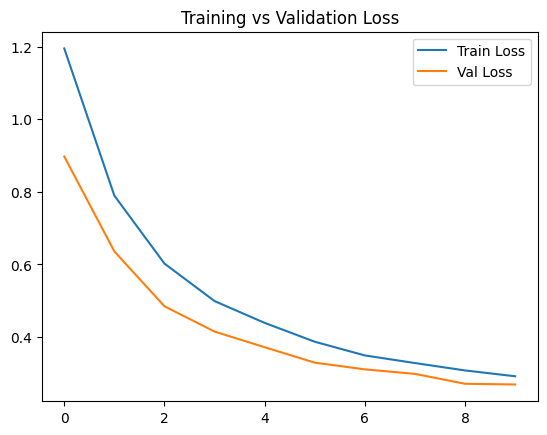

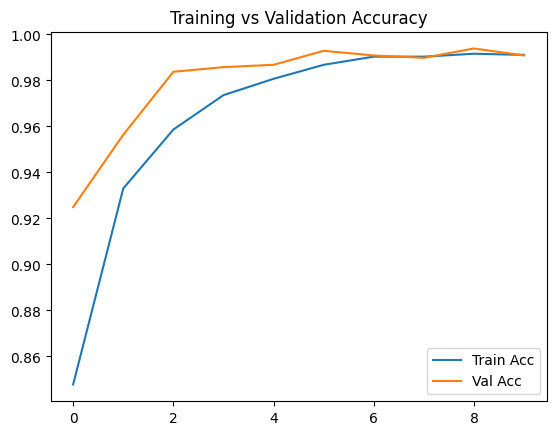

In [ ]:
!pip install tensorflow
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ✅ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ✅ Load Data
train_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_train.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# ⚠️ Only map labels if they are in text like 'cataract'/'normal'
# Here labels are already 0 and 1 → So skip mapping!

# ✅ Split Features and Labels
X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values

# ✅ Normalize features
max_value = np.max(X_train)  # Same scaling for both
X_train = X_train / max_value
X_test = X_test / max_value

# ✅ Define MLP Model
model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.005), input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.005)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Output layer for Binary classification
])

# ✅ Compile Model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ✅ Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# ✅ Train Model
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=10,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)
model.save('/content/drive/MyDrive/Colab Notebooks/anterior_eye/mlp_resnet_model.h5')


# ✅ Evaluate on Test Data
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc * 100:.2f}%")

# ✅ Plot Loss Curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# ✅ Plot Accuracy Curve
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


roc-auc

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ✅ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ✅ Load Data
train_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_train.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# ✅ Split Features and Labels
X_train, y_train = train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values
X_test, y_test = test_df.iloc[:, :-1].values, test_df.iloc[:, -1].values

# ✅ Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ✅ Apply PCA (optional: reduce dimensions to 100 or tune based on variance)
pca = PCA(n_components=100)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# ✅ Define MLP Model with BatchNorm + Dropout
model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# ✅ Compile Model
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ✅ Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ✅ Train Model
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=30,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)

# ✅ Save Model
model.save('/content/drive/MyDrive/Colab Notebooks/anterior_eye/mlp_resnet_model_revised.h5')

# ✅ Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"🎯 Test Accuracy: {acc * 100:.2f}%")

# ✅ Plot Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

📈 ROC AUC Score: 0.9967


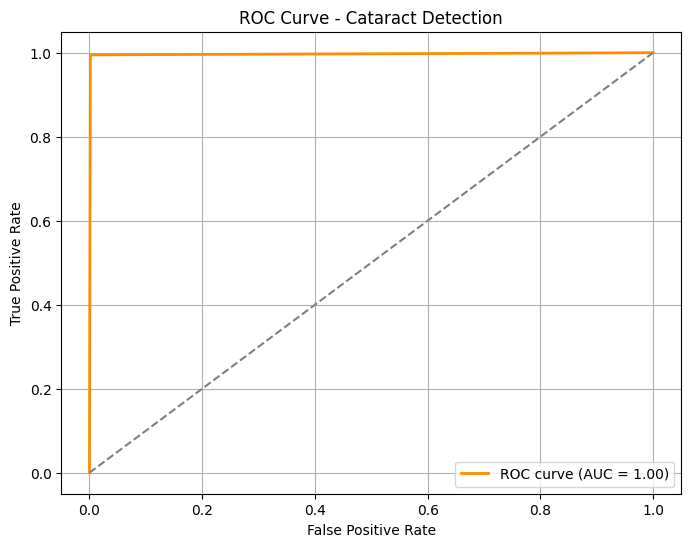

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from tensorflow.keras.models import load_model

# ---- Load test data ----
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv")
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/anterior_eye/vgg_slit_model.h5")

# ---- Convert string labels if needed ----
if df_test['label'].dtype == object:
    df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})

# ---- Separate features and labels ----
X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

# ---- Predict probabilities ----
y_pred_proba = mlp_model.predict(X_test)

# ---- Convert probabilities to binary predictions ----
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

# ---- ROC Curve and AUC ----
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n📈 ROC AUC Score: {auc:.4f}")

# ---- Plot ROC Curve ----
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Cataract Detection")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


testing

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import VGG16 # Import VGG16 instead of ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input # Use VGG16 preprocessing
from tensorflow.keras.preprocessing import image

# Load trained MLP model
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/anterior_eye/vgg_slit_model.h5")

# Load VGG16 model (feature extractor only) - Use the same model as in training
vgg16_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Load and preprocess image
img_path = '/content/drive/MyDrive/Colab Notebooks/anterior_eye/test/cataract/10_JPG_jpg.rf.60c0165f6221e7d3b7bc8e16b9214652_0_9858.png'  # change to your image path
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array) # Use VGG16's preprocessing

# Extract features using VGG16
features = vgg16_model.predict(img_array)
# Flatten features
features = features.flatten()
features = features.reshape(1, -1)  # Reshape to (1, num_features)

# Predict using MLP
pred = mlp_model.predict(features)
pred_label = (pred >= 0.5).astype(int).flatten()[0]

# Output Result
if pred_label == 1:
    print("Prediction: 🩺 Cataract Detected")
else:
    print("Prediction: 👀 Normal Eye")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Prediction: 🩺 Cataract Detected


evaluation

In [ ]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---- Load test features from CSV ----
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/anterior_eye/slit_vgg_test.csv")

# ---- Load trained MLP model correctly ----
mlp_model = load_model("/content/drive/MyDrive/Colab Notebooks/anterior_eye/vgg_slit_model.h5")

# ✅ Check if labels need mapping before applying
# If labels are already 0 and 1, this step is skipped.
if df_test['label'].dtype == object:  # If labels are strings (like 'cataract', 'normal')
    df_test['label'] = df_test['label'].map({'cataract': 1, 'normal': 0})

# ---- Split features and labels ----
X_test = df_test.iloc[:, :-1].values  # Features
y_test = df_test.iloc[:, -1].values   # Labels

# ---- Predict test set ----
y_pred = mlp_model.predict(X_test)

# ---- Convert probability predictions to binary (0 or 1) ----
y_pred = (y_pred >= 0.5).astype(int)  # Threshold at 0.5
# ---- Flatten predictions ----
y_pred = y_pred.flatten().astype(int)

# ---- Evaluate performance ----
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy: {accuracy * 100:.2f}%")

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Cataract"]))

print("\n🔹 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
🎯 Test Accuracy: 99.59%

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       643
    Cataract       1.00      0.99      1.00       589

    accuracy                           1.00      1232
   macro avg       1.00      1.00      1.00      1232
weighted avg       1.00      1.00      1.00      1232


🔹 Confusion Matrix:
[[642   1]
 [  4 585]]
